# 02 - Patrones de vulnerabilidades

## Introducción
Este notebook analiza patrones transversales de vulnerabilidades y hallazgos CodeQL a partir de `analysis.json`.

## Pregunta que responde
**¿Qué riesgos se repiten, en qué componentes se concentran y cómo priorizar mitigaciones de forma defendible?**

### Cómo interpretar esta sección
- Se observa severidad para estimar urgencia.
- Se revisan artifacts vulnerables para ubicar concentración técnica.
- Se incorporan CWE, `fix_available`, correlaciones y reglas CodeQL frecuentes.

### Por qué importa en ciberseguridad
Los patrones repetidos suelen indicar deuda sistémica, no incidentes aislados. Identificarlos mejora priorización y eficiencia de remediación.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'results' / 'analysis.json').exists():
            return candidate
    return Path.cwd()


analysis_path = find_project_root() / 'data' / 'results' / 'analysis.json'
analysis = json.loads(analysis_path.read_text(encoding='utf-8'))

vuln_rows = []
repo_rows = []
codeql_rows = []

for repo in analysis.get('repositories', []) or []:
    repo_name = repo.get('name', 'unknown')
    repo_rows.append({
        'repo': repo_name,
        'components': repo.get('sbom', {}).get('total_components', 0),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
    })

    for item in repo.get('vulnerabilities', {}).get('items', []) or []:
        vuln_rows.append({
            'repo': repo_name,
            'id': item.get('id', 'unknown'),
            'severity': item.get('severity', 'Unknown') or 'Unknown',
            'artifact': item.get('artifact', 'unknown') or 'unknown',
            'artifact_type': item.get('artifact_type', 'unknown') or 'unknown',
            'cwe': item.get('cwe', 'Unknown') or 'Unknown',
            'fix_available': bool(item.get('fix_available', False)),
        })

    for issue in repo.get('codeql', {}).get('items', []) or []:
        codeql_rows.append({
            'repo': repo_name,
            'rule_id': issue.get('rule_id', 'unknown') or 'unknown',
            'level': issue.get('level', 'unknown') or 'unknown',
        })

df_repo = pd.DataFrame(repo_rows)
df_vulns = pd.DataFrame(vuln_rows)
df_codeql = pd.DataFrame(codeql_rows)

if df_repo.empty:
    df_repo = pd.DataFrame(columns=['repo', 'components', 'vulnerabilities'])
if df_vulns.empty:
    df_vulns = pd.DataFrame(columns=['repo','id','severity','artifact','artifact_type','cwe','fix_available'])
if df_codeql.empty:
    df_codeql = pd.DataFrame(columns=['repo','rule_id','level'])

display(df_vulns.head())

,repo,id,severity,artifact,artifact_type,cwe,fix_available
0,deepagents,GHSA-jm6w-m3j8-898g,High,nltk,python,CWE-306,True
1,deepagents,GHSA-gfwx-w7gr-fvh7,Medium,nltk,python,CWE-79,True
2,deepagents,GHSA-5239-wwwm-4pmq,Low,pygments,python,CWE-400,True
3,deepagents,GHSA-r75f-5x8p-qvmc,Critical,litellm,python,Unknown,True
4,deepagents,GHSA-v4p8-mg3p-g94g,High,litellm,python,Unknown,True


In [2]:
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
severity_counts = df_vulns['severity'].value_counts().reindex(severity_order, fill_value=0)
top_artifacts = df_vulns['artifact'].value_counts().head(10)
top_cwe = df_vulns['cwe'].value_counts().head(10)
fix_counts = df_vulns['fix_available'].map({True: 'Fix disponible', False: 'Sin fix'}).value_counts()
by_type = df_vulns['artifact_type'].value_counts().head(10)

display(severity_counts.to_frame('count'))
display(top_artifacts.to_frame('count'))
display(top_cwe.to_frame('count'))
display(fix_counts.to_frame('count'))
display(by_type.to_frame('count'))

,count
severity,
Critical,1
High,5
Medium,12
Low,4
Unknown,0


,count
artifact,
uuid,8
nltk,3
litellm,3
pygments,2
pypa/gh-action-pypi-publish,2
gradle/gradle-build-action,2
fast-xml-parser,1
@anthropic-ai/sdk,1


,count
cwe,
Unknown,16
CWE-400,2
CWE-200,2
CWE-306,1
CWE-79,1


,count
fix_available,
Fix disponible,21
Sin fix,1


,count
artifact_type,
npm,10
python,8
github-action,4


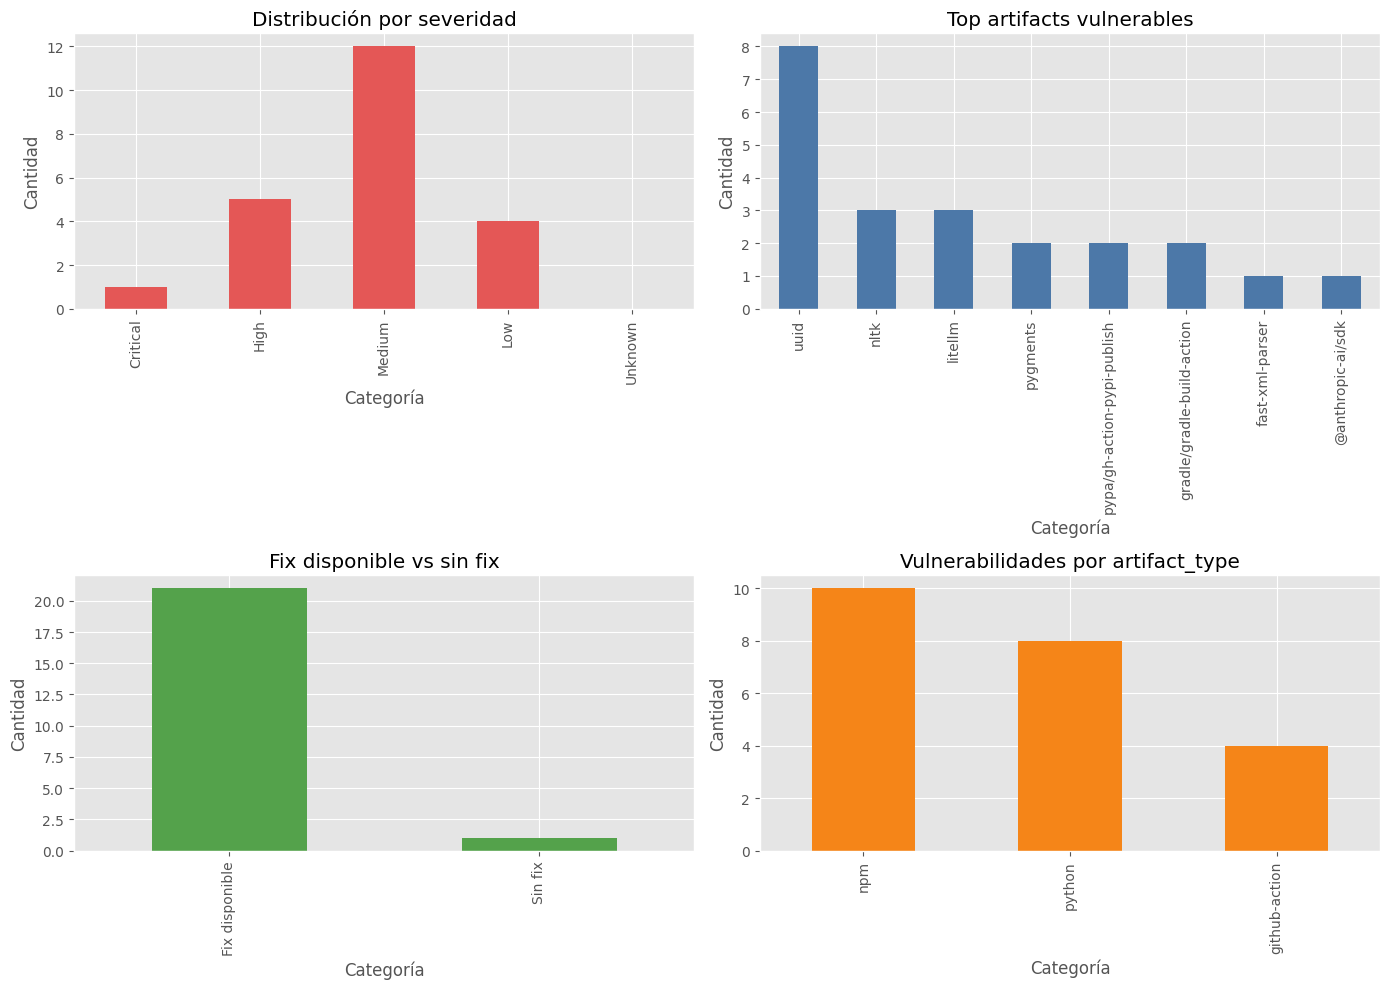

In [3]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

severity_counts.plot(kind='bar', ax=axes[0, 0], color='#E45756', title='Distribución por severidad')
top_artifacts.plot(kind='bar', ax=axes[0, 1], color='#4C78A8', title='Top artifacts vulnerables')
fix_counts.plot(kind='bar', ax=axes[1, 0], color='#54A24B', title='Fix disponible vs sin fix')
by_type.plot(kind='bar', ax=axes[1, 1], color='#F58518', title='Vulnerabilidades por artifact_type')

for ax in axes.ravel():
    ax.set_xlabel('Categoría')
    ax.set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

,repo,components,vulnerabilities
0,deepagents,2276,10
1,docs,502,5
2,langchain,2330,1
3,langsmith-go,31,0
4,langsmith-java,14,2
5,streaming-cookbook,899,4


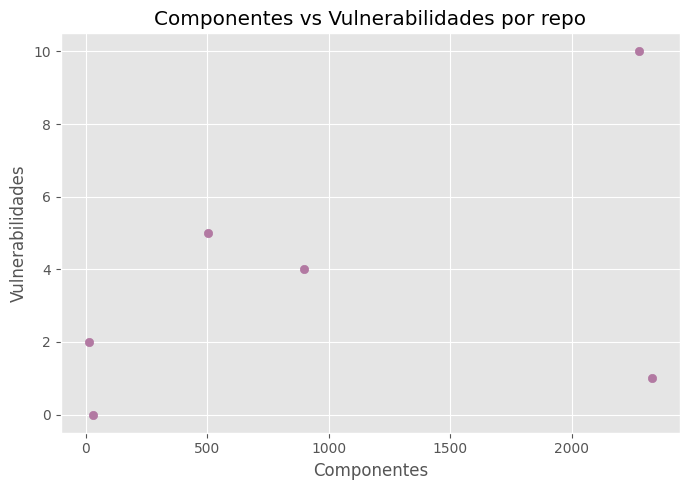

Pearson (components vs vulnerabilities): 0.4737


In [4]:
# Correlación componentes vs vulnerabilidades

df_repo_corr = df_repo.copy()
display(df_repo_corr)

plt.figure(figsize=(7, 5))
if not df_repo_corr.empty:
    plt.scatter(df_repo_corr['components'], df_repo_corr['vulnerabilities'], color='#B279A2')
    plt.xlabel('Componentes')
    plt.ylabel('Vulnerabilidades')
    plt.title('Componentes vs Vulnerabilidades por repo')
else:
    plt.text(0.5, 0.5, 'Sin datos', ha='center', va='center')
plt.tight_layout()
plt.show()

valid_pairs = df_repo_corr[['components', 'vulnerabilities']].dropna()
if len(valid_pairs) >= 2 and valid_pairs['components'].nunique() > 1 and valid_pairs['vulnerabilities'].nunique() > 1:
    corr = valid_pairs['components'].corr(valid_pairs['vulnerabilities'], method='pearson')
    print(f'Pearson (components vs vulnerabilities): {corr:.4f}')
else:
    print('Pearson no calculable con datos actuales (muestras insuficientes o sin variación).')

In [5]:
# CWEs transversales: en cuántos repos aparece cada CWE
if df_vulns.empty:
    cwe_cross = pd.DataFrame(columns=['cwe', 'repo_count'])
else:
    cwe_cross = (
        df_vulns[df_vulns['cwe'] != 'Unknown']
        .groupby('cwe')['repo']
        .nunique()
        .sort_values(ascending=False)
        .reset_index(name='repo_count')
    )

display(cwe_cross.head(20))

repeated_cwe = cwe_cross[cwe_cross['repo_count'] > 1]
print(f"CWEs presentes en más de un repo: {len(repeated_cwe)}")

,cwe,repo_count
0,CWE-400,2
1,CWE-200,1
2,CWE-306,1
3,CWE-79,1


CWEs presentes en más de un repo: 1


,count
rule_id,
py/clear-text-logging-sensitive-data,13
py/incomplete-url-substring-sanitization,8
py/overly-permissive-file,2
py/weak-sensitive-data-hashing,1


,count
level,
error,13
warning,11


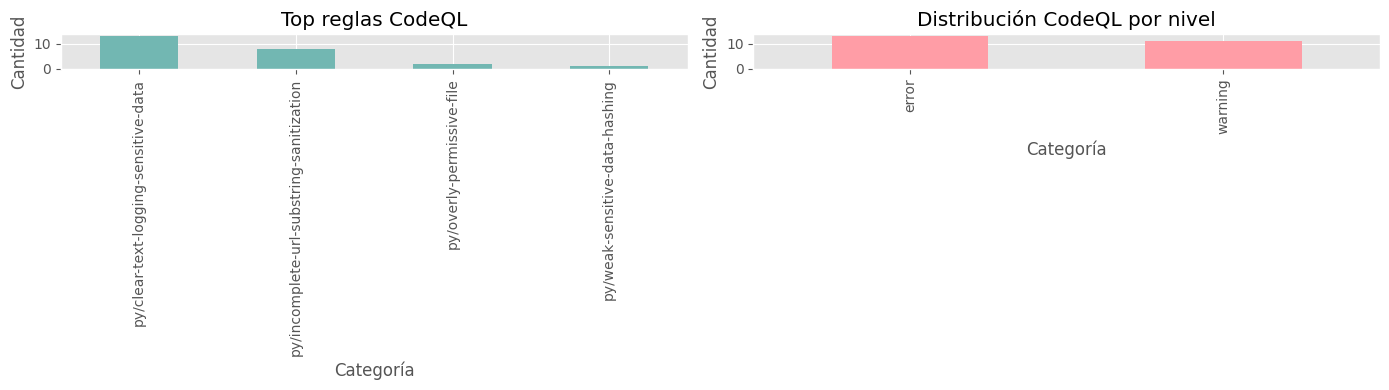

In [6]:
# Reglas CodeQL comunes y distribución por nivel
rule_counts = df_codeql['rule_id'].value_counts().head(10)
level_counts = df_codeql['level'].value_counts()

display(rule_counts.to_frame('count'))
display(level_counts.to_frame('count'))

if not rule_counts.empty or not level_counts.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    rule_counts.plot(kind='bar', ax=axes[0], color='#72B7B2', title='Top reglas CodeQL')
    level_counts.plot(kind='bar', ax=axes[1], color='#FF9DA6', title='Distribución CodeQL por nivel')
    for ax in axes:
        ax.set_xlabel('Categoría')
        ax.set_ylabel('Cantidad')
    plt.tight_layout()
    plt.show()
else:
    print('No hay issues de CodeQL para mostrar reglas/niveles.')

## Interpretación de patrones

### Severidad
Revisar severidad permite separar ruido de riesgo material. Un aumento de niveles **High/Critical** sugiere necesidad de mitigación prioritaria.

### Artifacts vulnerables
Los artifacts más afectados ayudan a localizar superficies de ataque repetidas (dependencias, librerías o imágenes base).

### CWE
**CWE** describe el tipo de debilidad (no una vulnerabilidad específica). Si un CWE aparece en varios repositorios, puede requerir controles transversales (guías, linters, hardening de plantillas).

### `fix_available`
Cuando `fix_available` es verdadero, existe ruta de remediación más directa (upgrade/patch). Esto impacta la priorización porque reduce tiempo de exposición.

### Correlación componentes vs vulnerabilidades
Una correlación positiva sugiere que repos con más componentes tienden a exponer más hallazgos. No implica causalidad, pero sí apoya decisiones de higiene de dependencias.

### Reglas CodeQL frecuentes
Reglas repetidas indican patrones de codificación inseguros o controles faltantes en revisión de código.

### Patrones en múltiples repositorios
Si un patrón aparece en más de un repo, el riesgo deja de ser local y pasa a ser organizacional.

## Conclusión parcial
Este notebook muestra qué tipos de vulnerabilidades se repiten, qué componentes concentran más riesgo y qué hallazgos podrían priorizarse por severidad, frecuencia o disponibilidad de fix.
